# 01 — Data Loading & Exploratory Analysis

First pass over the DOL disclosure data for FY2026 Q3:
- `data/raw/LCA_Disclosure_Data_FY2026_Q3.csv` — H-1B (and E-3/H-1B1) Labor Condition Applications
- `data/raw/PERM_Disclosure_Data_FY2026_Q3.csv` — PERM labor certifications (green card sponsorship)

Goal here is just to understand shape, quality, and headline distributions before we narrow in
on MBA-relevant roles in notebook 02.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_lca, load_perm, annual_wage  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "outputs" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## Load both files

Both CSVs are pre-allocated to the full fiscal year, so most rows are blank placeholders —
`load_lca`/`load_perm` (see `src/data_loader.py`) drop those and parse dates for us.

In [2]:
lca = load_lca()
perm = load_perm()

print(f"LCA (H-1B/E-3/H-1B1) records: {len(lca):,}")
print(f"PERM records: {len(perm):,}")

LCA (H-1B/E-3/H-1B1) records: 437,496
PERM records: 112,550


In [3]:
lca.info()

<class 'pandas.DataFrame'>
RangeIndex: 437496 entries, 0 to 437495
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   CASE_NUMBER             437496 non-null  str           
 1   CASE_STATUS             437496 non-null  str           
 2   RECEIVED_DATE           437496 non-null  datetime64[us]
 3   DECISION_DATE           437496 non-null  datetime64[us]
 4   VISA_CLASS              437496 non-null  str           
 5   JOB_TITLE               437496 non-null  str           
 6   SOC_CODE                437496 non-null  str           
 7   SOC_TITLE               437496 non-null  str           
 8   FULL_TIME_POSITION      437496 non-null  str           
 9   TOTAL_WORKER_POSITIONS  437496 non-null  float64       
 10  NEW_EMPLOYMENT          437496 non-null  float64       
 11  CONTINUED_EMPLOYMENT    437496 non-null  float64       
 12  CHANGE_EMPLOYER         437496 non-null  

In [4]:
perm.info()

<class 'pandas.DataFrame'>
RangeIndex: 112550 entries, 0 to 112549
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   CASE_NUMBER             112550 non-null  str           
 1   CASE_STATUS             112550 non-null  str           
 2   RECEIVED_DATE           112550 non-null  datetime64[us]
 3   DECISION_DATE           112550 non-null  datetime64[us]
 4   OCCUPATION_TYPE         112550 non-null  str           
 5   EMP_BUSINESS_NAME       112550 non-null  str           
 6   EMP_CITY                112550 non-null  str           
 7   EMP_STATE               112396 non-null  str           
 8   EMP_COUNTRY             112547 non-null  str           
 9   EMP_NAICS               112545 non-null  float64       
 10  PWD_SOC_CODE            112496 non-null  str           
 11  PWD_SOC_TITLE           112347 non-null  str           
 12  JOB_TITLE               112507 non-null  

## Data quality: missingness

In [5]:
missing_lca = (lca.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_lca[missing_lca > 0]

PREVAILING_WAGE          100.0
WAGE_RATE_OF_PAY_TO      100.0
WAGE_RATE_OF_PAY_FROM    100.0
PW_WAGE_LEVEL             10.3
WILLFUL_VIOLATOR           2.4
H_1B_DEPENDENT             2.4
dtype: float64

In [6]:
missing_perm = (perm.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_perm[missing_perm > 0]

JOB_OPP_WAGE_TO           100.0
JOB_OPP_WAGE_FROM         100.0
PRIMARY_WORKSITE_STATE      3.9
PRIMARY_WORKSITE_CITY       3.9
PWD_SOC_TITLE               0.2
EMP_STATE                   0.1
dtype: float64

## Case status: how often do filings actually get certified?

This is the headline number international students care about — of the cases DOL has
decided, what fraction were certified vs denied/withdrawn?

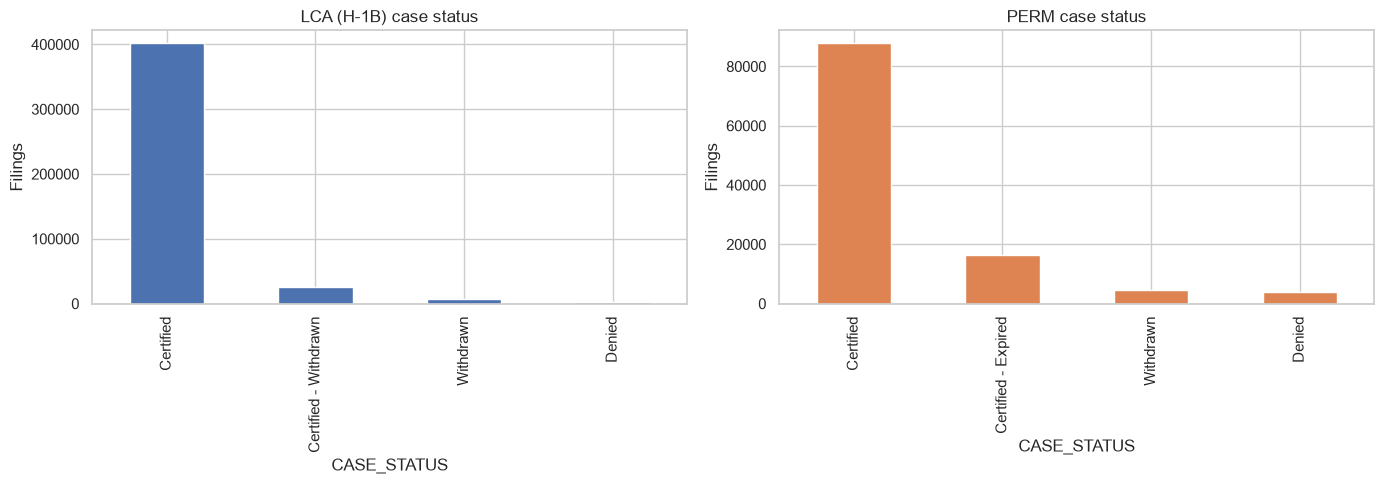

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lca["CASE_STATUS"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("LCA (H-1B) case status")
axes[0].set_ylabel("Filings")

perm["CASE_STATUS"].value_counts(dropna=False).plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("PERM case status")
axes[1].set_ylabel("Filings")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_case_status.png", dpi=150)
plt.show()

In [8]:
lca_decided = lca[lca["CASE_STATUS"].isin(["Certified", "Certified - Withdrawn", "Denied"])]
lca_cert_rate = (lca_decided["CASE_STATUS"] != "Denied").mean()
print(f"LCA certification rate (of decided cases): {lca_cert_rate:.1%}")

perm_decided = perm[perm["CASE_STATUS"].isin(["Certified", "Certified - Expired", "Denied"])]
perm_cert_rate = (perm_decided["CASE_STATUS"] != "Denied").mean()
print(f"PERM certification rate (of decided cases): {perm_cert_rate:.1%}")

LCA certification rate (of decided cases): 99.4%
PERM certification rate (of decided cases): 96.4%


LCA (H-1B) approval rates are famously high — the real bottleneck for H-1B is the annual
lottery/cap, which never shows up in this data at all (only *filed* LCAs, and most LCAs are
filed only after an employer already won a cap slot or the role is cap-exempt). PERM denial
rates, by contrast, are a more direct signal of employer/role risk since there's no lottery.

## Visa class breakdown (LCA)

In [9]:
lca["VISA_CLASS"].value_counts()

VISA_CLASS
H-1B               426952
E-3 Australian       7671
H-1B1 Chile          1654
H-1B1 Singapore      1219
Name: count, dtype: int64

## Top occupations by filing volume

In [10]:
top_soc_lca = lca["SOC_TITLE"].value_counts().head(20)
top_soc_lca

SOC_TITLE
Software Developers                                   128109
Data Scientists                                        19752
Information Technology Project Managers                14387
Computer Systems Engineers/Architects                  13778
Software Quality Assurance Analysts and Testers        13745
Computer Programmers                                   11325
Computer and Information Systems Managers               9014
Computer Systems Analysts                               8754
Business Intelligence Analysts                          8640
Financial and Investment Analysts                       7953
Mechanical Engineers                                    7257
Accountants and Auditors                                6712
Electronics Engineers, Except Computer                  6257
Electrical Engineers                                    5766
Management Analysts                                     5722
Operations Research Analysts                            5703
Market Researc

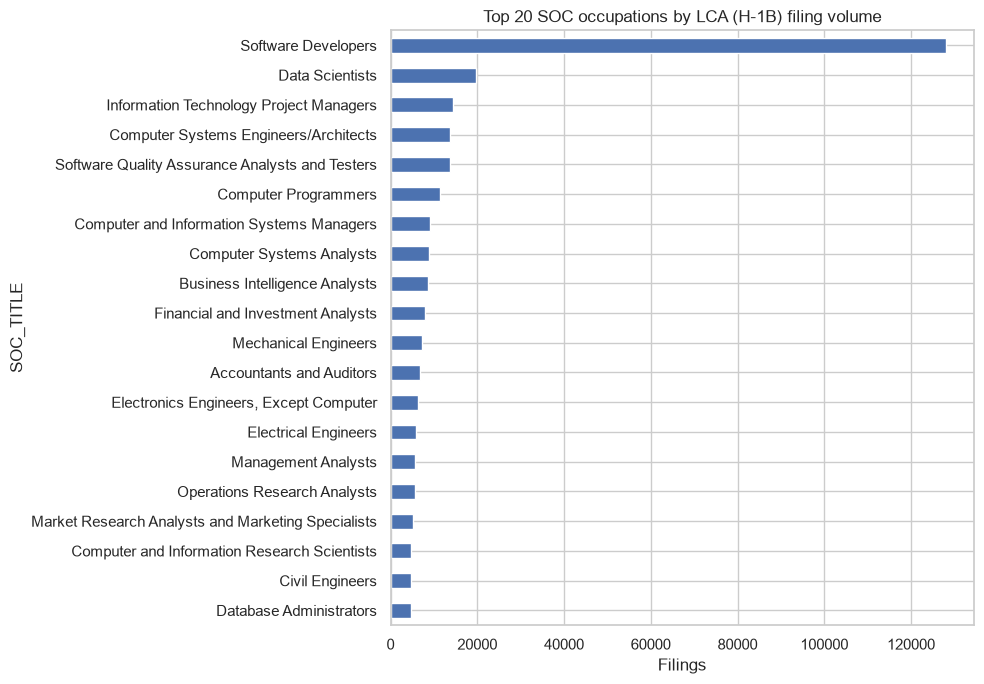

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
top_soc_lca.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Top 20 SOC occupations by LCA (H-1B) filing volume")
ax.set_xlabel("Filings")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_top_soc_lca.png", dpi=150)
plt.show()

In [12]:
top_soc_perm = perm["PWD_SOC_TITLE"].value_counts().head(20)
top_soc_perm

PWD_SOC_TITLE
Software Developers                                24838
Computer Systems Analysts                           4938
Fast Food and Counter Workers                       2986
Project Management Specialists                      2755
Data Scientists                                     2713
Meat, Poultry, and Fish Cutters and Trimmers        2304
Medical and Clinical Laboratory Technologists       2179
Software Quality Assurance Analysts and Testers     1972
Landscaping and Groundskeeping Workers              1674
Accountants and Auditors                            1620
Computer and Information Systems Managers           1581
Helpers--Production Workers                         1533
Nursing Assistants                                  1519
Electronics Engineers, Except Computer              1450
Team Assemblers                                     1424
Business Intelligence Analysts                      1351
Mechanical Engineers                                1262
Financial and Inv

## Filing volume over time

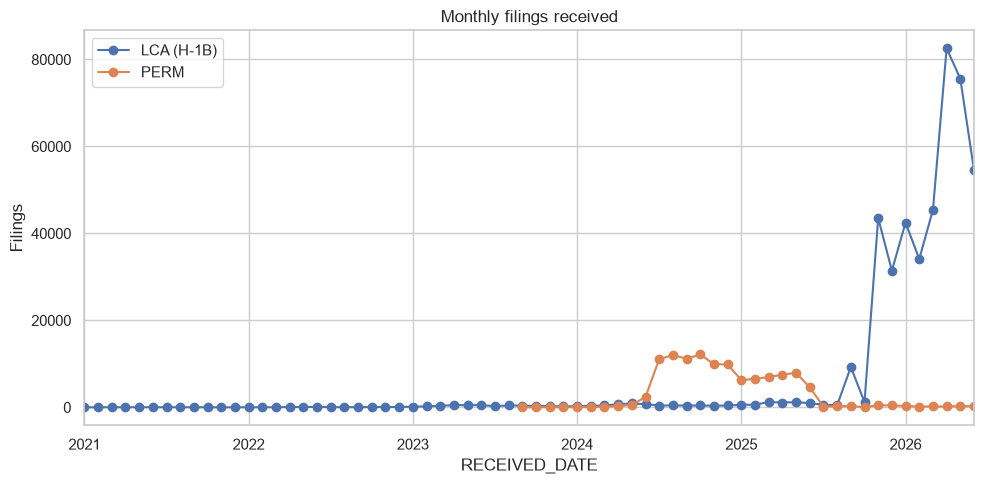

In [13]:
monthly_lca = lca.set_index("RECEIVED_DATE").resample("ME").size()
monthly_perm = perm.set_index("RECEIVED_DATE").resample("ME").size()

fig, ax = plt.subplots()
monthly_lca.plot(ax=ax, label="LCA (H-1B)", marker="o")
monthly_perm.plot(ax=ax, label="PERM", marker="o")
ax.set_title("Monthly filings received")
ax.set_ylabel("Filings")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_monthly_filings.png", dpi=150)
plt.show()

## Wages

Normalize everything to an annualized figure so hourly/weekly/monthly roles are comparable.

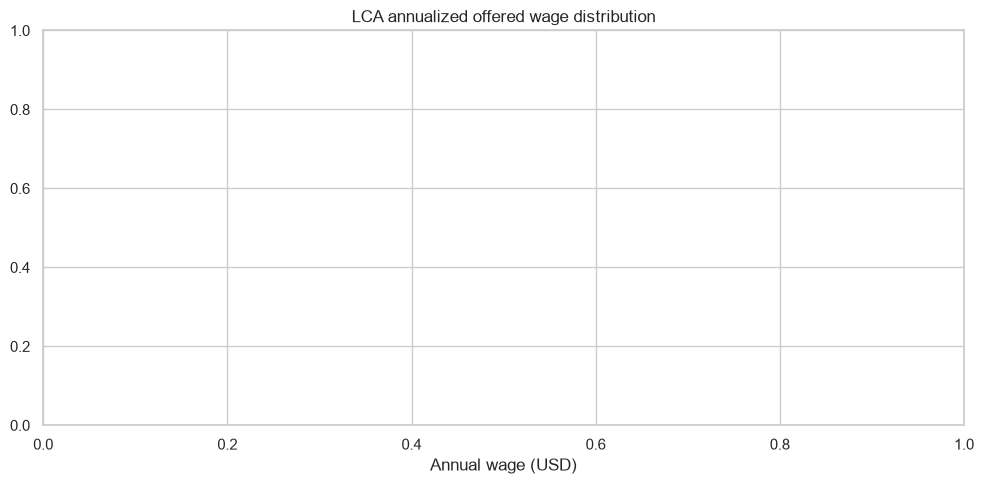

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ANNUAL_WAGE_FROM, dtype: float64


In [14]:
lca["ANNUAL_WAGE_FROM"] = annual_wage(lca["WAGE_RATE_OF_PAY_FROM"], lca["WAGE_UNIT_OF_PAY"])
lca_wage = lca[(lca["ANNUAL_WAGE_FROM"] > 20_000) & (lca["ANNUAL_WAGE_FROM"] < 500_000)]

fig, ax = plt.subplots()
sns.histplot(lca_wage["ANNUAL_WAGE_FROM"], bins=60, ax=ax, color="#4C72B0")
ax.set_title("LCA annualized offered wage distribution")
ax.set_xlabel("Annual wage (USD)")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_wage_distribution.png", dpi=150)
plt.show()

print(lca_wage["ANNUAL_WAGE_FROM"].describe())

## Geography: where are sponsoring employers located?

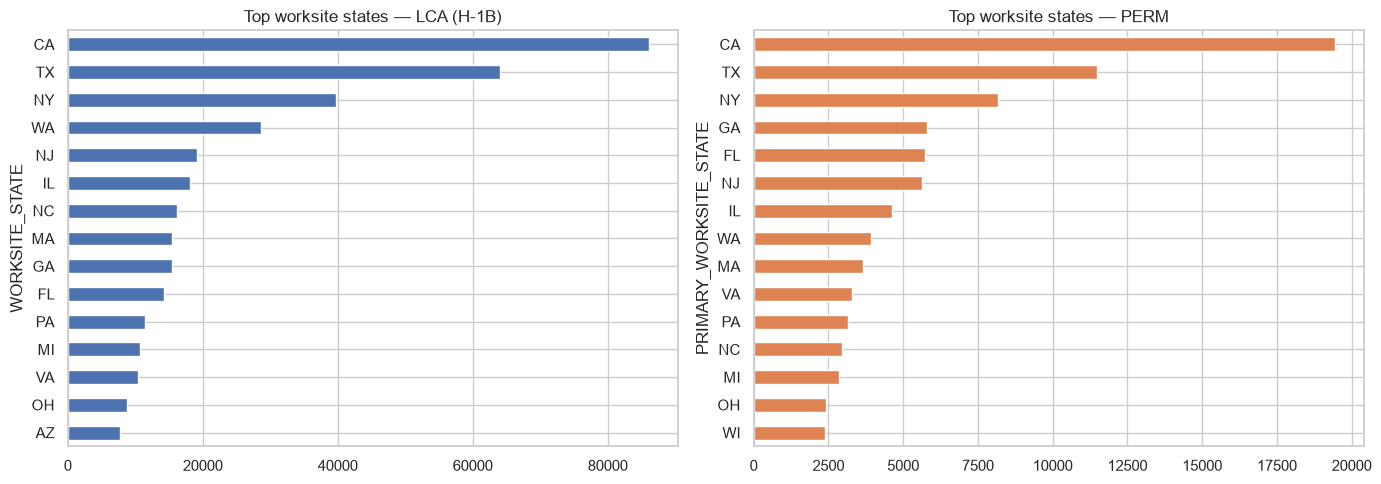

In [15]:
top_states_lca = lca["WORKSITE_STATE"].value_counts().head(15)
top_states_perm = perm["PRIMARY_WORKSITE_STATE"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_states_lca.sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Top worksite states — LCA (H-1B)")
top_states_perm.sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Top worksite states — PERM")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_top_states.png", dpi=150)
plt.show()

## Top sponsoring employers

In [16]:
lca["EMPLOYER_NAME"].value_counts().head(20)

EMPLOYER_NAME
Amazon.com Services LLC                                      13686
Google LLC                                                    7486
COGNIZANT TECHNOLOGY SOLUTIONS US CORP                        5779
Apple Inc.                                                    5682
Ernst & Young U.S. LLP                                        5494
Meta Platforms, Inc                                           5279
Microsoft Corporation                                         5159
INFOSYS LIMITED                                               4589
Tesla, Inc.                                                   2931
JPMorgan Chase & Co.                                          2788
Deloitte Consulting LLP                                       2633
NVIDIA Corporation                                            2467
Amazon Development Center U.S., Inc.                          2434
Amazon Web Services, Inc.                                     2421
WAL-MART ASSOCIATES, INC.                       

In [17]:
perm["EMP_BUSINESS_NAME"].value_counts().head(20)

EMP_BUSINESS_NAME
Microsoft Corporation             1458
Management Health Systems, LLC    1399
Labor Guys, LLC                   1143
Stoughton Trailers, LLC            937
NVIDIA Corporation                 843
Deloitte Consulting LLP            783
JCG Foods of Georgia, LLC          772
JPMORGAN CHASE & CO.               761
WAL-MART ASSOCIATES, INC.          627
Ernst & Young U.S. LLP             565
 Koch Foods of Gadsden, LLC        563
Cisco Systems, Inc.                551
Salesforce, Inc.                   476
FMR LLC                            434
Case Farms Processing, Inc         427
ByteDance Inc.                     392
Tesla, Inc.                        390
Bloomberg L.P.                     358
TW Services, Inc                   340
Oracle America, Inc.               335
Name: count, dtype: int64

## Save lightweight summaries for reuse

These are small aggregate CSVs (not the raw data) so they're safe to commit and reuse
directly in the dashboard later.

In [18]:
lca["SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "lca_top_occupations.csv")
perm["PWD_SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "perm_top_occupations.csv")
lca["EMPLOYER_NAME"].value_counts().rename("filings").head(200).to_csv(PROCESSED_DIR / "lca_top_employers.csv")
perm["EMP_BUSINESS_NAME"].value_counts().rename("filings").head(200).to_csv(PROCESSED_DIR / "perm_top_employers.csv")

print("Saved summary CSVs to", PROCESSED_DIR)

Saved summary CSVs to /Users/jaime/Local Documents/GitHub/h1b_analysis/data/processed


## Open questions heading into notebook 02

1. Neither file exposes a "minimum degree required" field — how do we approximate
   "MBA-reachable" roles from SOC code / job title alone? (see `src/mba_occupations.py`)
2. Which employers sponsor MBA-relevant roles specifically, not just tech roles in general?
3. Do certification/denial rates differ meaningfully by occupation tier or employer?
4. Where geographically do MBA-relevant sponsorships concentrate vs. the overall market?
5. What's the wage premium (or discount) for MBA-relevant roles vs. the broader population?